In [6]:
# import Libraries

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
# Load Dataset
df = pd.read_csv("StudentPerformanceFactors.csv")

# Initial Data Inspection
print("---- First 5 Rows ----")
print(df.head())

---- First 5 Rows ----
   Id  Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0   1             23          84                  Low                High   
1   2             19          64                  Low              Medium   
2   3             24          98               Medium              Medium   
3   4             29          89                  Low              Medium   
4   5             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Fa

In [8]:
print("\n---- Dataset Information ----")
print(df.info())

print("\n---- Missing Values ----")
print(df.isnull().sum())


---- Dataset Information ----
<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Id                          6607 non-null   int64
 1   Hours_Studied               6607 non-null   int64
 2   Attendance                  6607 non-null   int64
 3   Parental_Involvement        6607 non-null   str  
 4   Access_to_Resources         6607 non-null   str  
 5   Extracurricular_Activities  6607 non-null   str  
 6   Sleep_Hours                 6607 non-null   int64
 7   Previous_Scores             6607 non-null   int64
 8   Motivation_Level            6607 non-null   str  
 9   Internet_Access             6607 non-null   str  
 10  Tutoring_Sessions           6607 non-null   int64
 11  Family_Income               6607 non-null   str  
 12  Teacher_Quality             6529 non-null   str  
 13  School_Type                 6607 non-null  

In [10]:
# Handle Missing Values 

# Fill numeric columns with mean
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill categorical missing values with mode
df['Teacher_Quality'] = df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0])
df['Parental_Education_Level'] = df['Parental_Education_Level'].fillna(df['Parental_Education_Level'].mode()[0])
    
print("After cleaning:")
print(df.isnull().sum())

After cleaning:
Id                            0
Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Gender                        0
Exam_Score                    0
dtype: int64


In [11]:
#  Descriptive Statistics
print("\n--- Summary Statistics ---")
print(df.describe())


--- Summary Statistics ---
                Id  Hours_Studied   Attendance  Sleep_Hours  Previous_Scores  \
count  6607.000000    6607.000000  6607.000000   6607.00000      6607.000000   
mean   3304.000000      19.975329    79.977448      7.02906        75.070531   
std    1907.420946       5.990594    11.547475      1.46812        14.399784   
min       1.000000       1.000000    60.000000      4.00000        50.000000   
25%    1652.500000      16.000000    70.000000      6.00000        63.000000   
50%    3304.000000      20.000000    80.000000      7.00000        75.000000   
75%    4955.500000      24.000000    90.000000      8.00000        88.000000   
max    6607.000000      44.000000   100.000000     10.00000       100.000000   

       Tutoring_Sessions  Physical_Activity   Exam_Score  
count        6607.000000        6607.000000  6607.000000  
mean            1.493719           2.967610    67.190101  
std             1.230570           1.031231     4.088990  
min            

C:\Users\nidhi\AppData\Local\Temp\ipykernel_35680\799478718.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Exam_Score'], kde=True)


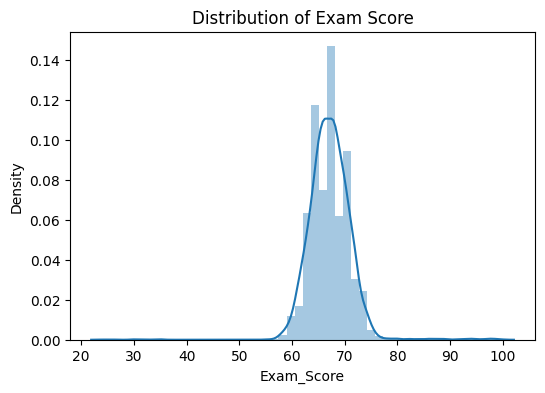

C:\Users\nidhi\AppData\Local\Temp\ipykernel_35680\799478718.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Hours_Studied'], kde=True)


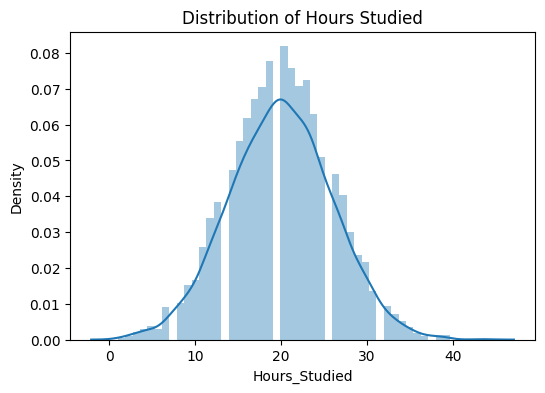

In [12]:
#  Univariate Analysis (Single Variable)

# Distribution of Exam Score
plt.figure(figsize=(6,4))
sns.distplot(df['Exam_Score'], kde=True)
plt.title("Distribution of Exam Score")
plt.show()

# Distribution of Hours Studied
plt.figure(figsize=(6,4))
sns.distplot(df['Hours_Studied'], kde=True)
plt.title("Distribution of Hours Studied")
plt.show()

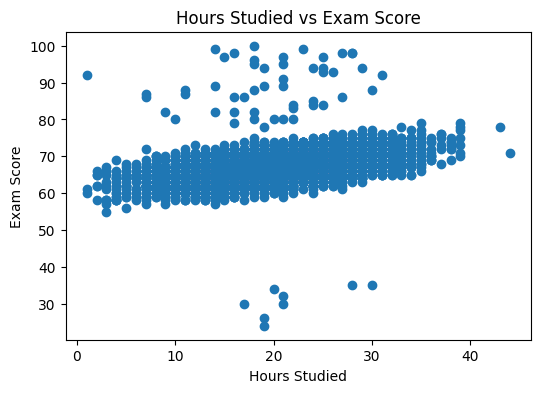

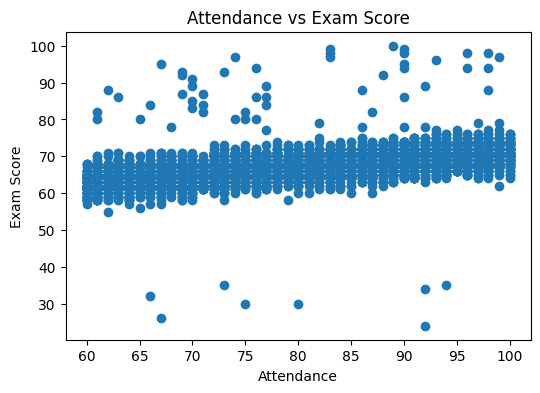

In [13]:
# Bivariate Analysis

# 1. Hours Studied vs Exam Score
plt.figure(figsize=(6,4))
plt.scatter(df['Hours_Studied'], df['Exam_Score'])
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs Exam Score")
plt.show()


# 2. Attendance vs Exam Score
plt.figure(figsize=(6,4))
plt.scatter(df['Attendance'], df['Exam_Score'])
plt.xlabel("Attendance")
plt.ylabel("Exam Score")
plt.title("Attendance vs Exam Score")
plt.show()

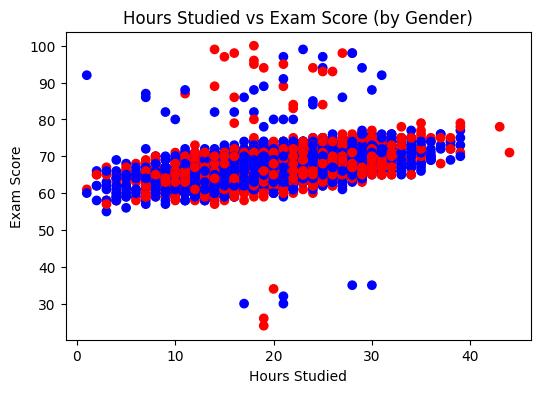

In [14]:
# Example: Color by Gender
colors = df['Gender'].map({'Male': 'blue', 'Female': 'red'})

plt.figure(figsize=(6,4))
plt.scatter(df['Hours_Studied'], df['Exam_Score'], c=colors)
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs Exam Score (by Gender)")
plt.show()

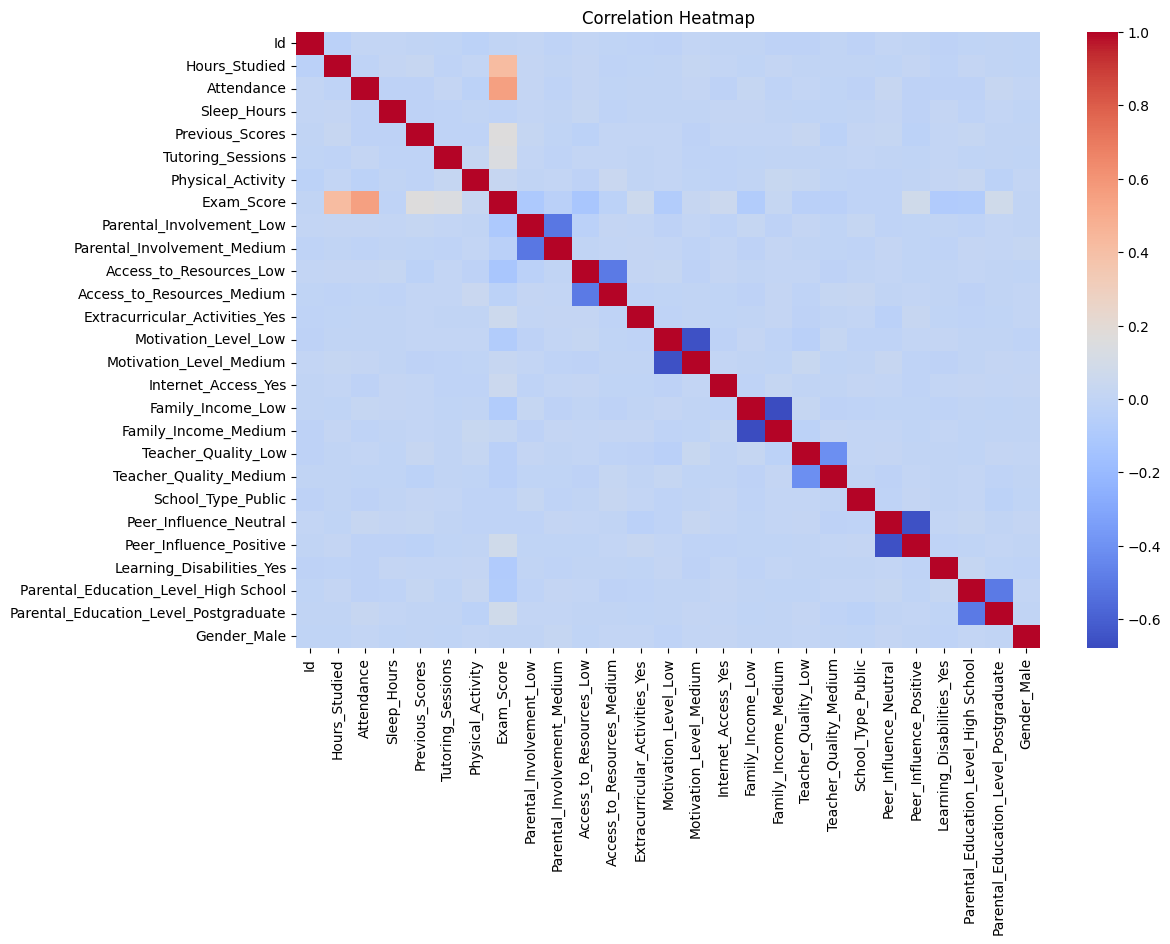

In [15]:
# Convert Categorical Data to Numeric (for correlation)
df_encoded = pd.get_dummies(df, drop_first=True)

# Correlation Heatmap
plt.figure(figsize=(12,8))
corr = df_encoded.corr()
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()